[Font] 已检测到中文字体: WenQuanYi Micro Hei
Device: cuda

Tweedie等式视角：从去噪器到先验得分
去噪器训练噪声水平 eps = (5/255)^2 = 0.000384
Tweedie等式: ∇log p_ε(x) = (D_ε(x) - x) / ε
PnP-ULA中: 先验得分步 = (δ/ε)(D_ε(x) - x)
这等价于: δ * ∇log p_ε(x)


  0%|          | 0/200 [00:00<?, ?it/s]


Initial NRMSE: 0.1174
Initial PSNR: 21.61 dB
Initial SSIM: 0.6959

Result NRMSE: 0.0664
Result PSNR: 26.58 dB
Result SSIM: 0.8117

不确定性量化分析


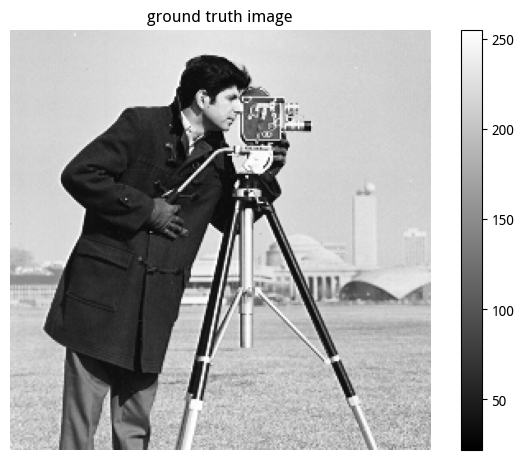

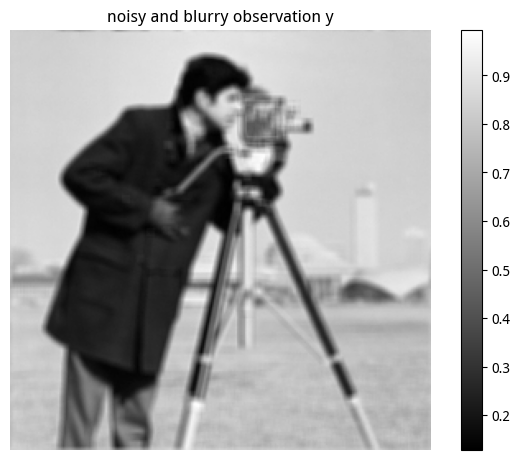

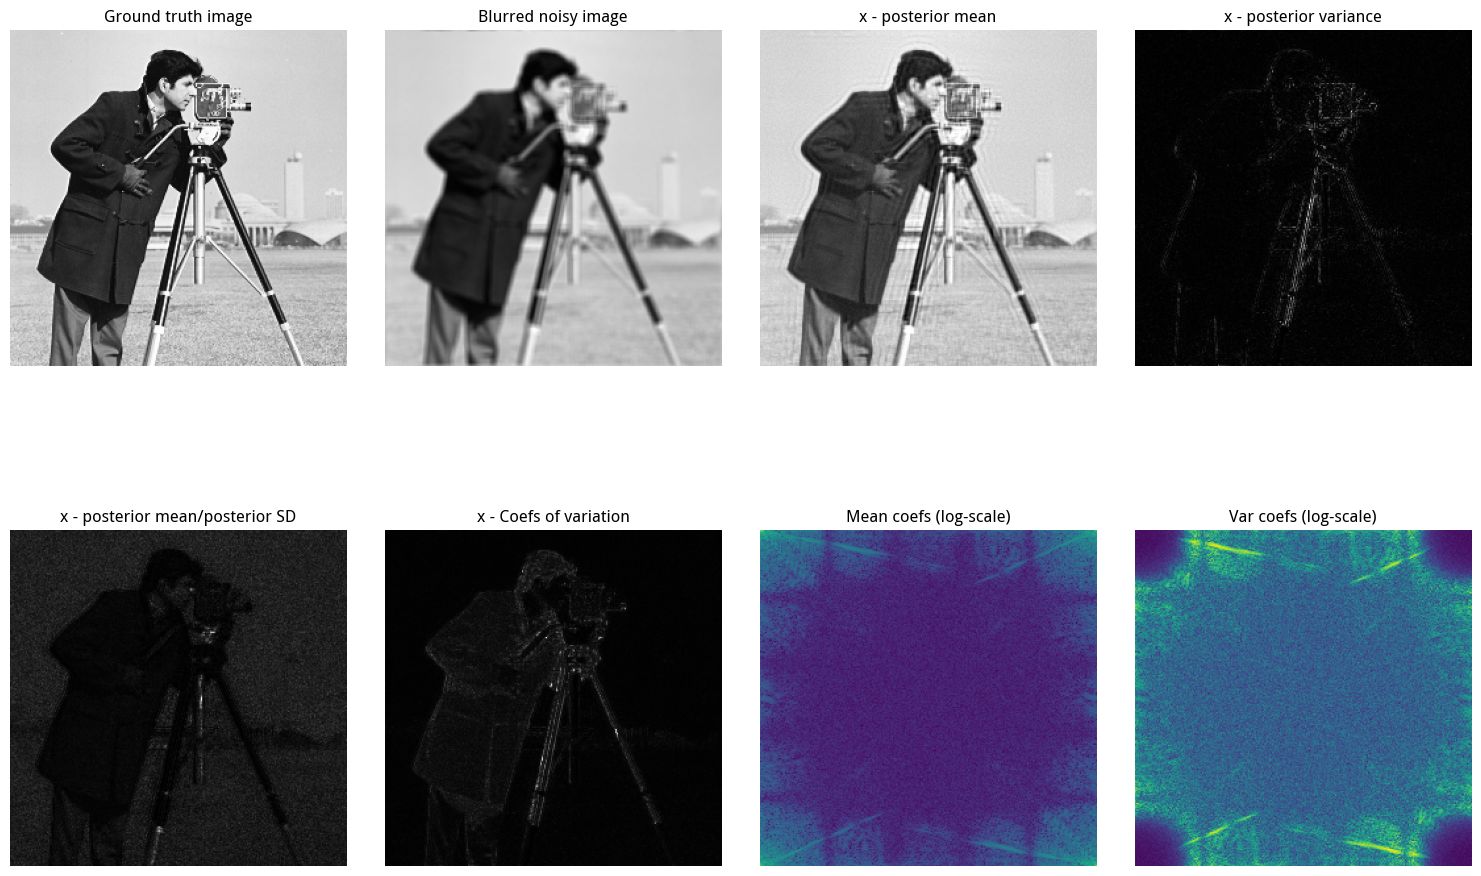

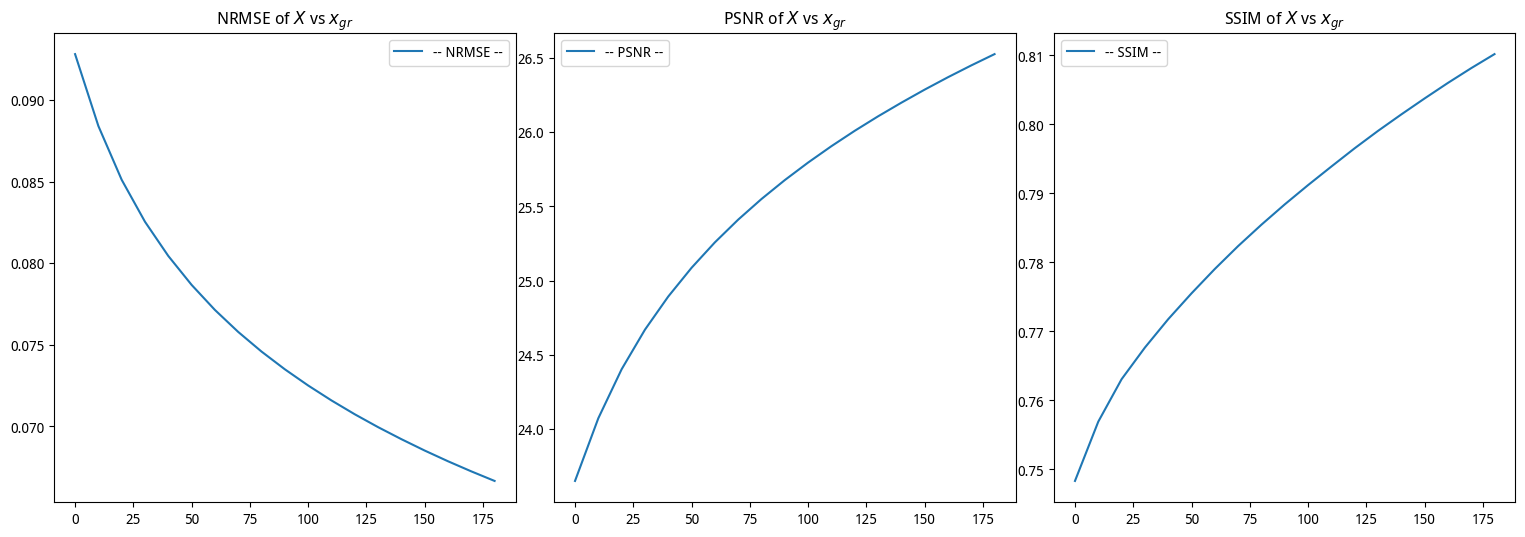

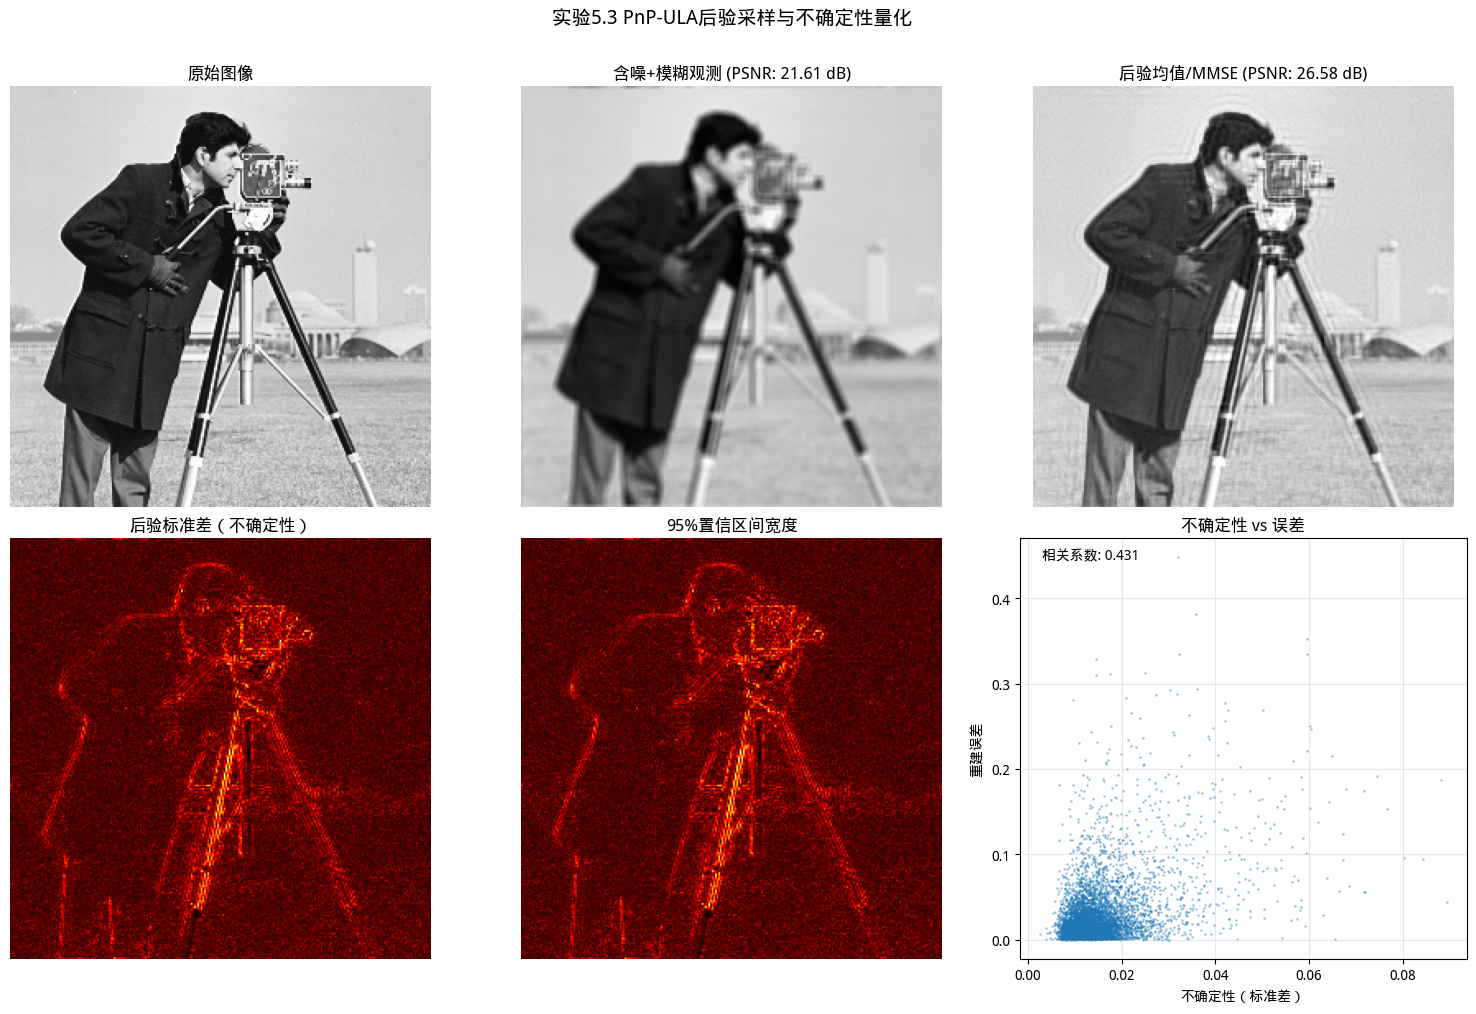

平均不确定性: 0.0152
最大不确定性: 0.1102
最小不确定性: 0.0017
不确定性-误差相关性: 0.431


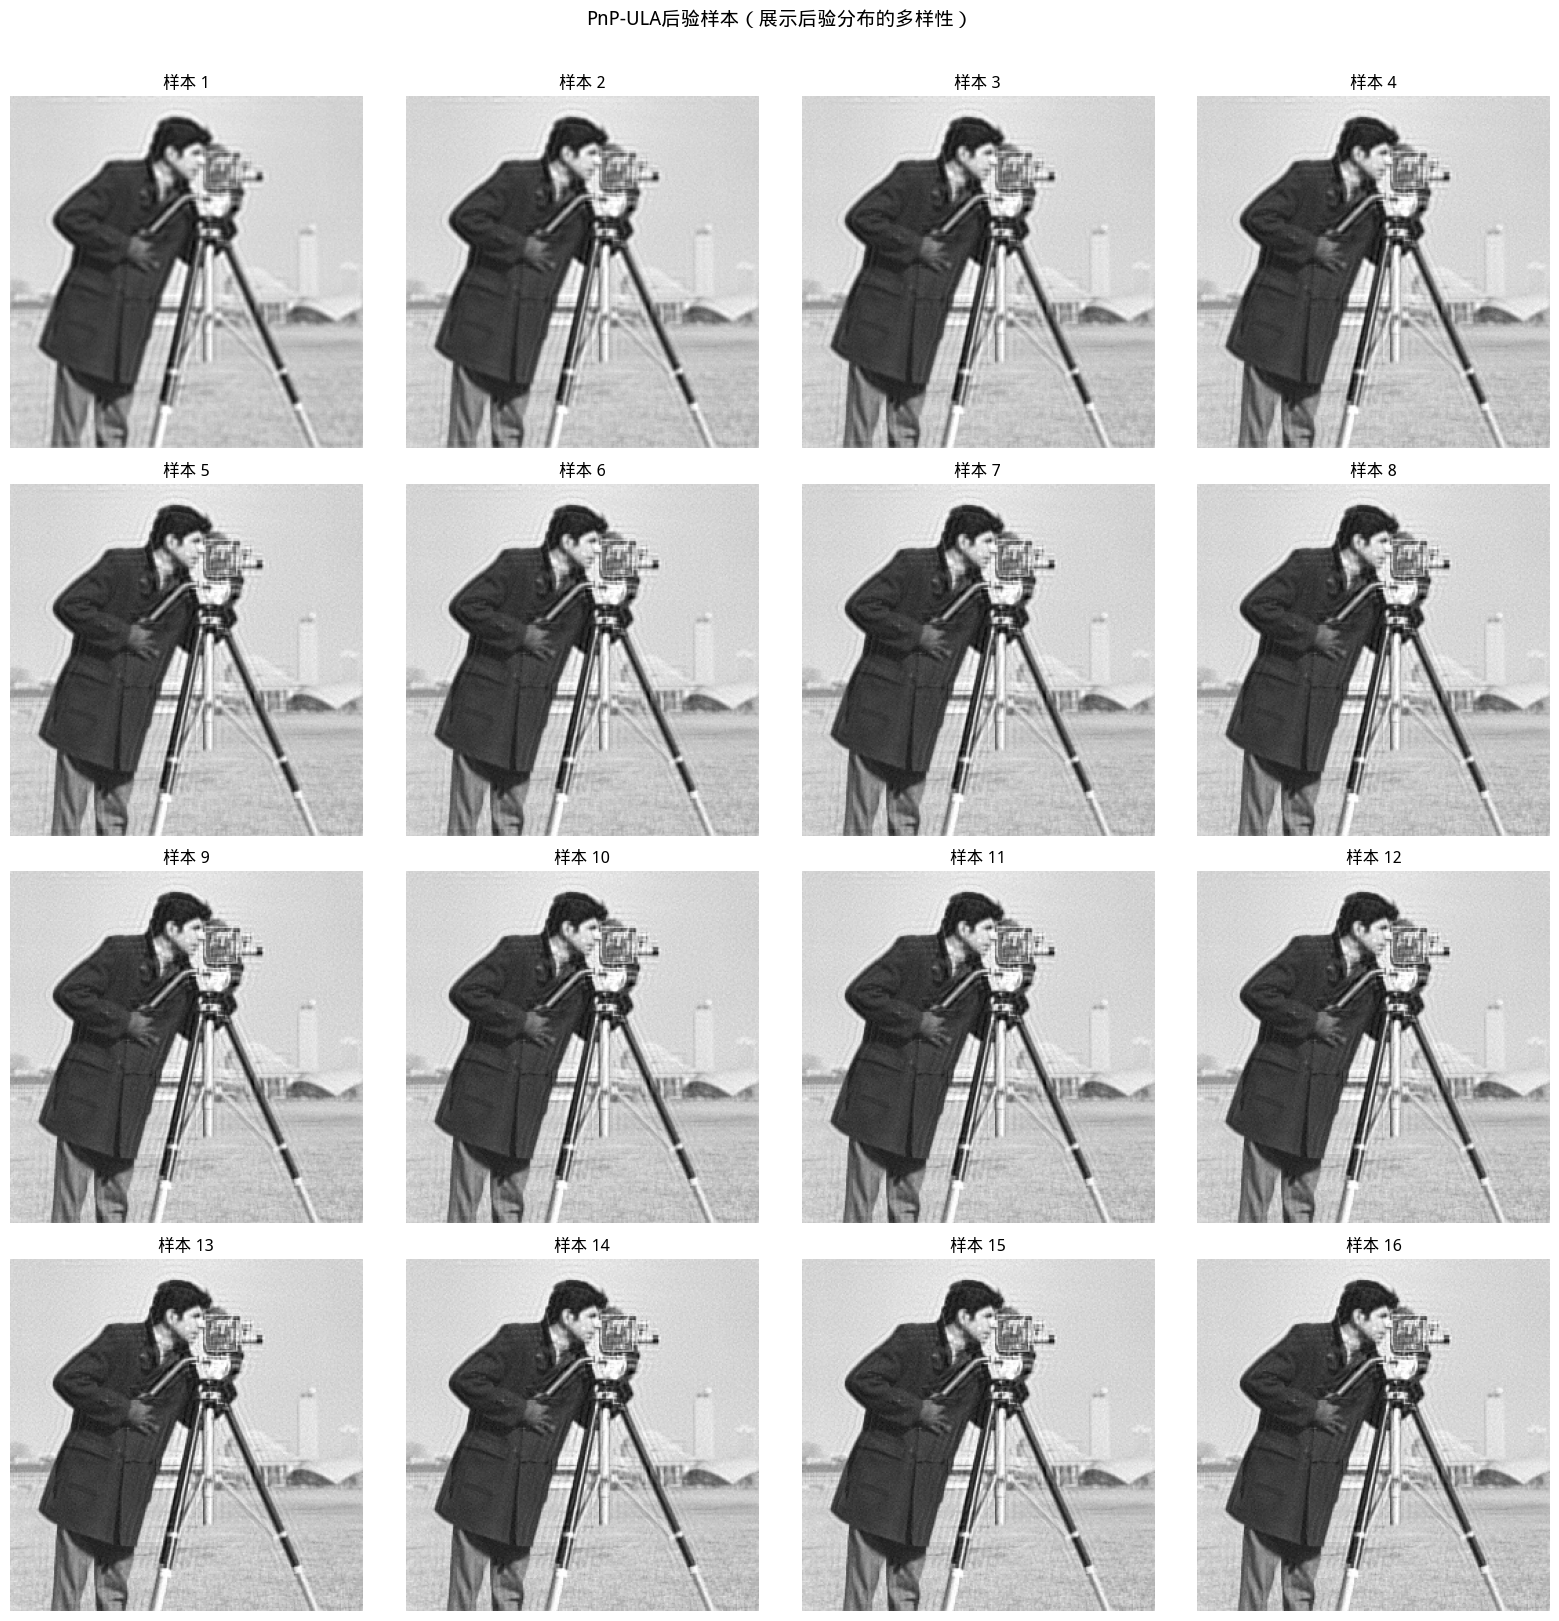


展示了 16 个后验样本
观察：不同样本展示了后验分布的多样性
  - 共享相似的全局结构（先验约束）
  - 细节存在差异（数据一致性与先验的权衡）

实验5.3 总结
1. PnP-ULA实现：用去噪器替换先验梯度的采样算法
   核心：Tweedie等式 → 先验得分 = (D_ε(x)-x)/ε
2. 后验采样：生成了多个后验样本，估计了后验均值和方差
3. 不确定性量化：
   - 后验标准差提供像素级的不确定性度量
   - 置信区间给出重建的统计置信度
   - 不确定性与重建误差正相关
4. MAP vs MMSE：
   - 最终样本（接近MAP）提供'最可能'的重建
   - 后验均值（MMSE）提供'平均意义下最好'的重建
   - MMSE通常视觉效果更平滑，MAP保留更多细节


In [7]:
"""
实验5.3 PnP-ULA后验采样与不确定性量化
对应章节：5.5（PnP框架：用去噪器替换先验梯度）
素材来源：Mathematics.../Teaching Unit 2/labs/lab2_PnP_sol.ipynb
  - Cell 3-6: 导入、图像加载、模糊算子、含噪观测
  - Cell 8-10: 似然函数、梯度、Lipschitz常数
  - Cell 11-12: 去噪器加载、算法参数
  - Cell 13: Markov_kernel 函数（PnP-ULA和PPnP-ULA）
  - Cell 14-15: 步长选择、初始化
  - Cell 16-17: 主采样循环（含welford在线统计）
  - Cell 18-20: 结果评估与可视化
  辅助模块：lab2_PnP.zip -> sampling_tools/ (welford, blur_operators, measures, plots)

与第4章实验4.6的区别：
  - 本实验聚焦于第5章的Tweedie等式视角
  - 增加了对Tweedie替换的显式展示
  - 增加了不确定性量化的详细分析

运行前提：
  1. sampling_tools/ 和 Pretrained_models/ 已拷贝到当前目录
  2. 需要GPU和预训练RealSN-DnCNN模型
"""

import math
import torch
import numpy as np
import time as time
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    """自动检测系统中可用的中文字体，兼容 Windows / Linux"""
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Source Han Sans SC', 'AR PL UMing CN',
            'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)
torch.manual_seed(42)

import sys
import os

# ★ sampling_tools 已拷贝到当前目录，无需外部路径
PARENT_DIR = os.path.dirname(os.path.abspath(''))  # 当前目录
if PARENT_DIR not in sys.path:
    sys.path.append(PARENT_DIR)

from sampling_tools import *

# 显式 fallback：确保关键函数已导入（防止 __init__.py 通配符静默失败）
from sampling_tools.plots import plot_im, plots
from sampling_tools.blur_operators import blur_operators
from sampling_tools.measures import NRMSE, PSNR, SSIM
from sampling_tools.welford import welford
from sampling_tools.load_model import load_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ============================================================
# 加载图像（取自 lab2_PnP_sol Cell 5，cman.png已拷贝到当前目录）
# ============================================================
SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
im = np.array(Image.open(os.path.join(SCRIPT_DIR, "cman.png")))
plot_im(im, "ground truth image")

x = torch.Tensor(im/255.).to(device)

# ============================================================
# 模糊算子（取自 lab2_PnP_sol Cell 6）
# ============================================================
kernel_len = [5,5]
size = [im.shape[0],im.shape[1]]
type_blur = "uniform"
A, AT, AAT_norm = blur_operators(kernel_len, size, type_blur, device)

# ============================================================
# 含噪观测（取自 lab2_PnP_sol Cell 7）
# ============================================================
y0 = A(x)

BSNRdb = 40
sigma = torch.linalg.matrix_norm(A(x)-torch.mean(A(x)), ord='fro')/math.sqrt(torch.numel(x)*10**(BSNRdb/10))

y = y0 + sigma * torch.randn_like(x)
plot_im(y, "noisy and blurry observation y")

# ============================================================
# 似然与梯度（取自 lab2_PnP_sol Cell 8-10）
# ============================================================
f = lambda x,A : (torch.linalg.matrix_norm(y-A(x), ord='fro')**2.0)/(2.0*sigma**2)
gradf = lambda x,A,AT : AT(A(x)-y)/sigma**2
L_y = AAT_norm/(sigma**2)

# ============================================================
# 去噪器（取自 lab2_PnP_sol Cell 11）
# ★ 第5章视角：去噪器通过Tweedie等式提供先验得分
#   score_prior = (D_ε(x) - x) / ε
# ============================================================
L_net = 1.0
model = load_model(os.path.join(SCRIPT_DIR, 'Pretrained_models', 'RealSN_DnCNN_noise5.pth'), device)
denoise = lambda x: (x - model(x[None][None].to(device))[0][0]).detach()

# Tweedie等式视角展示
print("\n" + "=" * 60)
print("Tweedie等式视角：从去噪器到先验得分")
print("=" * 60)
print(f"去噪器训练噪声水平 eps = (5/255)^2 = {(5/255)**2:.6f}")
print("Tweedie等式: ∇log p_ε(x) = (D_ε(x) - x) / ε")
print("PnP-ULA中: 先验得分步 = (δ/ε)(D_ε(x) - x)")
print("这等价于: δ * ∇log p_ε(x)")

# ============================================================
# 算法参数（取自 lab2_PnP_sol Cell 12）
# ============================================================
alpha = 1
eps =  (5/255)**2
max_lambd = 1.0/((2.0*alpha*L_net)/eps+4.0*L_y)
lambd_frac = 0.99
lambd = max_lambd*lambd_frac

C_upper_lim = torch.tensor(1).to(device)
C_lower_lim = torch.tensor(0).to(device)

# ============================================================
# PnP-ULA Markov核（取自 lab2_PnP_sol Cell 13）
# ★ 第5章注：X_{m+1} = X_m - δ∇f(X_m) + (αδ/ε)(D_ε(X_m)-X_m) + √(2δ)Z
#   其中 (D_ε(X_m)-X_m)/ε = ∇log p_ε(X_m) (Tweedie等式)
# ============================================================
projbox = lambda x: torch.clamp(x, min = C_lower_lim, max = C_upper_lim)

def Markov_kernel(X, delta, projected):
    if projected:
        return projbox(X - delta * gradf(X,A,AT) + alpha*delta/eps*(denoise(X)-X) + math.sqrt(2*delta) * torch.randn_like(X))
    else:
        return X - delta * gradf(X,A,AT) + alpha*delta/eps*(denoise(X)-X) + delta/lambd*(projbox(X)-X) + math.sqrt(2*delta) * torch.randn_like(X)

# ============================================================
# 步长选择（取自 lab2_PnP_sol Cell 14）
# ============================================================
projected = True

if projected:
    delta_max = (1.0)/(L_net/eps+L_y)
else:
    delta_max = (1.0/3.0)/((alpha*L_net)/eps+L_y+1/lambd)
delta_frac = 0.99
delta = delta_max*delta_frac

# ============================================================
# 主采样循环（取自 lab2_PnP_sol Cell 15-17）
# ============================================================
maxit = 200        # 原始10000，此处缩小以便CPU快速演示
burnin = np.int64(maxit*0.05)
n_samples = np.int64(40)  # 原始2000，按比例缩小
X = y.clone()
MC_X = []
thinned_trace_counter = 0
thinning_step = np.int64(maxit/n_samples)

nrmse_values = []
psnr_values = []
ssim_values = []

start_time = time.time()
for i_x in tqdm(range(maxit)):

    # Update X
    X = Markov_kernel(X, delta, projected=projected)

    if i_x == burnin:
        # Initialise recording of sample summary statistics after burnin period
        post_meanvar = welford(X)
        absfouriercoeff = welford(torch.fft.fft2(X).abs())
        count=0
    elif i_x > burnin:
        # update the sample summary statistics
        post_meanvar.update(X)
        absfouriercoeff.update(torch.fft.fft2(X).abs())

        # collect quality measurements
        current_mean = post_meanvar.get_mean()
        nrmse_values.append(NRMSE(x, current_mean))
        psnr_values.append(PSNR(x, current_mean))
        ssim_values.append(SSIM(x, current_mean))

        # collect thinned trace
        if count == thinning_step-1:
            MC_X.append(X.detach().cpu().numpy())
            count = 0
        else:
            count += 1

end_time = time.time()
elapsed = end_time - start_time

# ============================================================
# 结果评估（取自 lab2_PnP_sol Cell 18-20）
# ============================================================
print(f"\nInitial NRMSE: {NRMSE(x,y):.4f}")
print(f"Initial PSNR: {PSNR(x,y):.2f} dB")
print(f"Initial SSIM: {SSIM(x,y):.4f}")

print(f"\nResult NRMSE: {NRMSE(post_meanvar.get_mean(),x):.4f}" )
print(f"Result PSNR: {PSNR(post_meanvar.get_mean(),x):.2f} dB")
print(f"Result SSIM: {SSIM(x,post_meanvar.get_mean()):.4f}")

plots(x, y, post_meanvar, absfouriercoeff, nrmse_values, psnr_values, ssim_values)


# ============================================================
# 不确定性量化分析（第5章新增）
# ============================================================
print("\n" + "=" * 60)
print("不确定性量化分析")
print("=" * 60)

# 后验均值与标准差
post_mean = post_meanvar.get_mean()
post_std = torch.sqrt(post_meanvar.get_var())

# 可视化不确定性
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第1行：原始、含噪、后验均值
axes[0][0].imshow(im, cmap='gray')
axes[0][0].set_title('原始图像')
axes[0][0].axis('off')

axes[0][1].imshow(y.cpu().numpy(), cmap='gray')
axes[0][1].set_title(f'含噪+模糊观测 (PSNR: {PSNR(x,y):.2f} dB)')
axes[0][1].axis('off')

axes[0][2].imshow(post_mean.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0][2].set_title(f'后验均值/MMSE (PSNR: {PSNR(post_mean,x):.2f} dB)')
axes[0][2].axis('off')

# 第2行：后验标准差、置信区间、误差vs不确定性
axes[1][0].imshow(post_std.cpu().numpy(), cmap='hot')
axes[1][0].set_title('后验标准差（不确定性）')
axes[1][0].axis('off')

# 95%置信区间宽度（近似）
q_low = post_mean - 2 * post_std
q_high = post_mean + 2 * post_std
ci_width = (q_high - q_low).cpu().numpy()
axes[1][1].imshow(ci_width, cmap='hot')
axes[1][1].set_title('95%置信区间宽度')
axes[1][1].axis('off')

# 不确定性与重建误差的关系
error = torch.abs(x - post_mean).cpu().numpy()
uncertainty = post_std.cpu().numpy()
axes[1][2].scatter(uncertainty.flatten()[::10], error.flatten()[::10],
                   alpha=0.3, s=1)
axes[1][2].set_xlabel('不确定性（标准差）')
axes[1][2].set_ylabel('重建误差')
axes[1][2].set_title('不确定性 vs 误差')
corr = np.corrcoef(uncertainty.flatten(), error.flatten())[0, 1]
axes[1][2].annotate(f'相关系数: {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction')
axes[1][2].grid(alpha=0.3)

fig.suptitle('实验5.3 PnP-ULA后验采样与不确定性量化', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('不确定性量化.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"平均不确定性: {torch.mean(post_std).item():.4f}")
print(f"最大不确定性: {torch.max(post_std).item():.4f}")
print(f"最小不确定性: {torch.min(post_std).item():.4f}")
print(f"不确定性-误差相关性: {corr:.3f}")


# ============================================================
# 多样本展示（后验分布的多样性）
# ============================================================
if len(MC_X) > 0:
    num_show = min(16, len(MC_X))
    step = max(1, len(MC_X) // num_show)
    selected = MC_X[::step][:num_show]

    ncols = 4
    nrows = (num_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
    for i in range(nrows * ncols):
        ax = axes[i // ncols][i % ncols] if nrows > 1 else axes[i]
        if i < len(selected):
            ax.imshow(selected[i], cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'样本 {i+1}')
        ax.axis('off')

    fig.suptitle('PnP-ULA后验样本（展示后验分布的多样性）', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('后验样本.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n展示了 {len(selected)} 个后验样本")
    print("观察：不同样本展示了后验分布的多样性")
    print("  - 共享相似的全局结构（先验约束）")
    print("  - 细节存在差异（数据一致性与先验的权衡）")


# ============================================================
# 实验总结
# ============================================================
print("\n" + "=" * 60)
print("实验5.3 总结")
print("=" * 60)
print("1. PnP-ULA实现：用去噪器替换先验梯度的采样算法")
print("   核心：Tweedie等式 → 先验得分 = (D_ε(x)-x)/ε")
print("2. 后验采样：生成了多个后验样本，估计了后验均值和方差")
print("3. 不确定性量化：")
print("   - 后验标准差提供像素级的不确定性度量")
print("   - 置信区间给出重建的统计置信度")
print("   - 不确定性与重建误差正相关")
print("4. MAP vs MMSE：")
print("   - 最终样本（接近MAP）提供'最可能'的重建")
print("   - 后验均值（MMSE）提供'平均意义下最好'的重建")
print("   - MMSE通常视觉效果更平滑，MAP保留更多细节")
